In [1]:
import os
import csv
import math
import time
import json
import random

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset, Dataset

import torchvision
from torchvision import transforms
from torchvision import models
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.datasets import VOCDetection

In [2]:
os.makedirs("./artifacts/", exist_ok=True)
os.makedirs("./artifacts/figures/", exist_ok=True)

In [3]:
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.12.0.dev20260222+cu128
torchvision: 0.26.0.dev20260221+cu128


In [4]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = False  
DATA_DIR = "./data"

BATCH_SIZE = 128
EPOCHS = 4 if FAST_MODE else 12

Device: cuda


# Часть A - Классификация на STL10

In [5]:
STL10_MEAN = (0.485, 0.456, 0.406)
STL10_STD  = (0.229, 0.224, 0.225)

tf_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])
tf_train_aug = transforms.Compose([
    transforms.RandomCrop(96, padding=12),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(STL10_MEAN, STL10_STD),
])

ds_train_full = torchvision.datasets.STL10(
    root=DATA_DIR, split='train', download=True, transform=tf_base
)
ds_train_aug = torchvision.datasets.STL10(
    root=DATA_DIR, split='train', transform=tf_train_aug, download=True
)
ds_test = torchvision.datasets.STL10(
    root=DATA_DIR, split='test', download=True, transform=tf_base
)

class_names = ds_train_full.classes
NUM_CLASSES = len(class_names)

print(f"Train full: {len(ds_train_full)}")
print(f"Test: {len(ds_test)}")
print(f"Classes: {class_names}")

Train full: 5000
Test: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [6]:
n_total = len(ds_train_full)
n_val = int(n_total * 0.2)
n_train = n_total - n_val

ds_train_base, ds_val_base = random_split(
    ds_train_full, 
    [n_train, n_val], 
    generator=torch.Generator().manual_seed(RANDOM_STATE)
)

train_loader = DataLoader(ds_train_base, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ds_val_base, batch_size=BATCH_SIZE, shuffle=False)

train_loader_aug = DataLoader(
    Subset(ds_train_aug, ds_train_base.indices), 
    batch_size=BATCH_SIZE, 
    shuffle=True
)
val_loader_aug = val_loader 

test_loader = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)

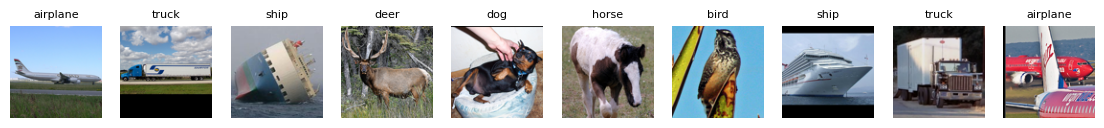

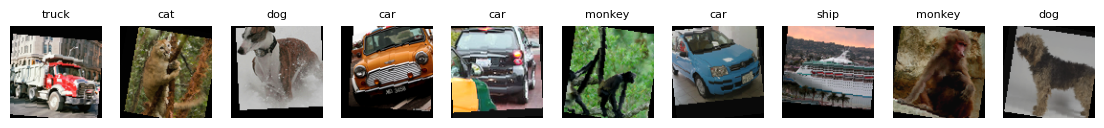

In [7]:
def denorm_stl(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def get_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_stl(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    return plt

get_images(train_loader).show()
aug_imgs = get_images(train_loader_aug)
aug_imgs.savefig("./artifacts/figures/augmentations_preview.png")
aug_imgs.show()

In [8]:
NUM_CLASSES = 10

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), 
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), 
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn = SimpleCNN().to(DEVICE)
print("Params:", count_params(cnn))  

Params: 4814666


In [9]:
with torch.no_grad():
    x0 = torch.randn(2, 3, 96, 96).to(DEVICE) 
    y0 = cnn(x0)
print("Input:", x0.shape, "Output logits:", y0.shape)

Input: torch.Size([2, 3, 96, 96]) Output logits: torch.Size([2, 10])


In [10]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen


def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history


def plot_history(history: dict, title: str = "") -> None:
    """
    Отрисовка процесса обучения
    history имеет структуру:
    {
    "train_loss": [...], "val_loss": [...],
    "train_acc": [...], "val_acc": [...]
    }
    """
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    
    plt.figure()
    plt.plot(epochs, history["train_loss"], "-o", label="train_loss")
    plt.plot(epochs, history["val_loss"], "-o", label="val_loss")
    
    best_val_loss_epoch = np.argmin(history["val_loss"]) + 1
    best_val_loss = np.min(history["val_loss"])
    plt.axvline(
        x=best_val_loss_epoch, color='green', linestyle='--',
        label=f'Best val_loss: epoch {best_val_loss_epoch} ({best_val_loss:.4f})'
    )
    
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join("./artifacts/figures/", f"{title} (loss).png"))
    plt.show()
    
    plt.figure()
    plt.plot(epochs, history["train_acc"], "-o", label="train_acc")
    plt.plot(epochs, history["val_acc"], "-o", label="val_acc")
    
    best_val_acc_epoch = np.argmax(history["val_acc"]) + 1
    best_val_acc = np.max(history["val_acc"])
    plt.axvline(
        x=best_val_acc_epoch, color='green', linestyle='--',
        label=f'Best val_acc: epoch {best_val_acc_epoch} ({best_val_acc:.4f})'
    )
    
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join("./artifacts/figures/", f"{title} (accuracy).png"))
    plt.show()

In [11]:
criterion = nn.CrossEntropyLoss()

def run_experiment(
    exp_id: str,
    train_loader,
    val_loader,
    model: nn.Module,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    epochs: int = EPOCHS
):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}


Experiment C1 (CNN-simple) | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 4814666
Epoch 01/12 | train loss 2.0039, acc 0.264 | val loss 1.6754, acc 0.368 | 3.6s
Epoch 02/12 | train loss 1.5460, acc 0.428 | val loss 1.5249, acc 0.423 | 3.4s
Epoch 03/12 | train loss 1.3442, acc 0.503 | val loss 1.3517, acc 0.503 | 3.4s
Epoch 04/12 | train loss 1.1288, acc 0.594 | val loss 1.4082, acc 0.511 | 3.4s
Epoch 05/12 | train loss 0.9326, acc 0.664 | val loss 1.2875, acc 0.547 | 3.4s
Epoch 06/12 | train loss 0.6981, acc 0.761 | val loss 1.4256, acc 0.536 | 3.5s
Epoch 07/12 | train loss 0.4983, acc 0.829 | val loss 1.4422, acc 0.554 | 3.5s
Epoch 08/12 | train loss 0.3043, acc 0.905 | val loss 1.6951, acc 0.580 | 3.4s
Epoch 09/12 | train loss 0.1722, acc 0.948 | val loss 1.9301, acc 0.572 | 3.4s
Epoch 10/12 | train loss 0.0940, acc 0.977 | val loss 2.1337, acc 0.571 | 3.4s
Epoch 11/12 | train loss 0.0532, acc 0.986 | val loss 2.4962, acc 0.565 | 3.4s
Epoch 12/12 | train loss 0.0317, acc 0.

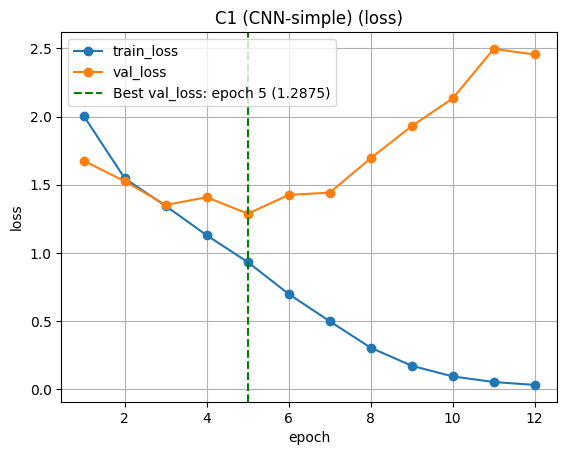

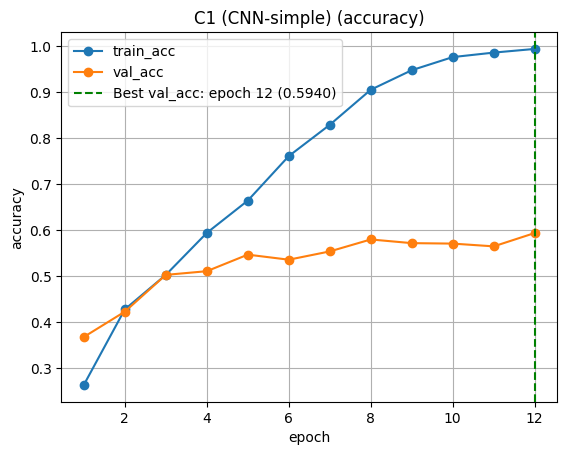

In [12]:
title = "C1 (CNN-simple)"

res_c1 = run_experiment(
    title,
    train_loader,
    val_loader,
    SimpleCNN(NUM_CLASSES)
)

plot_history(res_c1["history"], title=title)


Experiment C2 (CNN-simple + aug) | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 4814666
Epoch 01/12 | train loss 2.0926, acc 0.226 | val loss 1.8360, acc 0.300 | 9.0s
Epoch 02/12 | train loss 1.7536, acc 0.338 | val loss 1.6447, acc 0.382 | 9.0s
Epoch 03/12 | train loss 1.5921, acc 0.407 | val loss 1.5213, acc 0.429 | 9.1s
Epoch 04/12 | train loss 1.4836, acc 0.445 | val loss 1.5675, acc 0.404 | 9.1s
Epoch 05/12 | train loss 1.4751, acc 0.457 | val loss 1.3553, acc 0.502 | 8.9s
Epoch 06/12 | train loss 1.3677, acc 0.496 | val loss 1.2973, acc 0.517 | 9.0s
Epoch 07/12 | train loss 1.3299, acc 0.514 | val loss 1.3011, acc 0.515 | 9.3s
Epoch 08/12 | train loss 1.2681, acc 0.521 | val loss 1.2766, acc 0.525 | 9.3s
Epoch 09/12 | train loss 1.2620, acc 0.527 | val loss 1.2893, acc 0.518 | 9.1s
Epoch 10/12 | train loss 1.2278, acc 0.544 | val loss 1.1929, acc 0.550 | 9.1s
Epoch 11/12 | train loss 1.1820, acc 0.565 | val loss 1.2008, acc 0.551 | 8.9s
Epoch 12/12 | train loss 1.1192, 

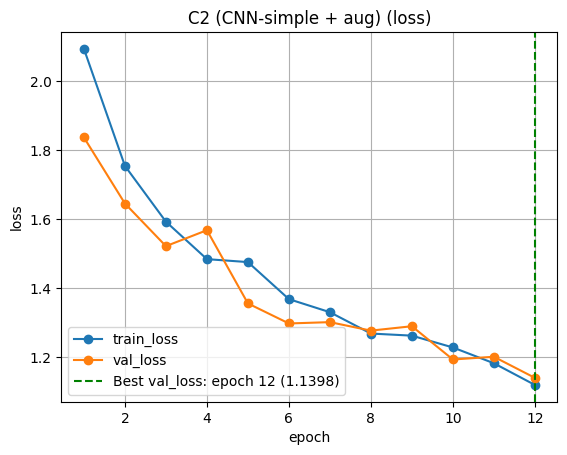

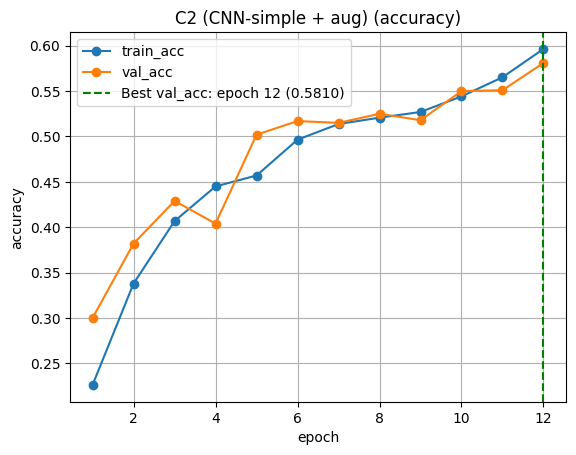

In [13]:
title = "C2 (CNN-simple + aug)"

res_c2 = run_experiment(
    title, 
    train_loader_aug,
    val_loader_aug,
    SimpleCNN(NUM_CLASSES), 
)

plot_history(res_c2["history"], title=title)

In [14]:
weights = ResNet18_Weights.IMAGENET1K_V1
tf_resnet_base = weights.transforms() 


ds_train_full_resnet = torchvision.datasets.STL10(
    root=DATA_DIR, split='train', download=False, transform=tf_resnet_base
)
ds_test_resnet = torchvision.datasets.STL10(
    root=DATA_DIR, split='test', download=False, transform=tf_resnet_base
)

n_total = len(ds_train_full_resnet)
n_val = int(n_total * 0.2)
n_train = n_total - n_val

ds_train_base_resnet, ds_val_base_resnet = random_split(
    ds_train_full_resnet, [n_train, n_val], 
    generator=torch.Generator().manual_seed(RANDOM_STATE)
)

train_loader_resnet = DataLoader(ds_train_base_resnet, batch_size=BATCH_SIZE, shuffle=True)
val_loader_resnet = DataLoader(ds_val_base_resnet, batch_size=BATCH_SIZE, shuffle=False)

print("train:", len(train_loader_resnet.dataset))
print("val:", len(val_loader_resnet.dataset))

train: 4000
val: 1000


In [15]:
def get_resnet18_head_only(num_classes=10):
    """
    Подготовка модели для C3
    """
    weights = ResNet18_Weights.IMAGENET1K_V1
    model = resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True
        
    print(f"Trainable params: {count_params(model)}")
    return model


def get_resnet18_finetune(num_classes=10):
    """
    Подготовка модели для C4
    """
    weights = ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    for name, param in model.named_parameters():
        if 'layer4' in name or 'fc' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    
    trainable = count_params(model)
    print(f"Trainable: {trainable:,} (layer4 + fc)")
    return model

Trainable params: 5130

Experiment C3 (ResNet18-Head-Only) | lr=0.001 weight_decay=0.0 epochs=12
Trainable params: 5130
Epoch 01/12 | train loss 1.4110, acc 0.622 | val loss 0.7015, acc 0.888 | 15.7s
Epoch 02/12 | train loss 0.5188, acc 0.905 | val loss 0.4180, acc 0.913 | 15.8s
Epoch 03/12 | train loss 0.3516, acc 0.925 | val loss 0.3393, acc 0.914 | 16.1s
Epoch 04/12 | train loss 0.2832, acc 0.933 | val loss 0.2953, acc 0.923 | 15.9s
Epoch 05/12 | train loss 0.2387, acc 0.946 | val loss 0.2677, acc 0.931 | 15.9s
Epoch 06/12 | train loss 0.2117, acc 0.952 | val loss 0.2525, acc 0.935 | 16.3s
Epoch 07/12 | train loss 0.1991, acc 0.951 | val loss 0.2387, acc 0.934 | 16.4s
Epoch 08/12 | train loss 0.1840, acc 0.956 | val loss 0.2315, acc 0.932 | 16.3s
Epoch 09/12 | train loss 0.1670, acc 0.961 | val loss 0.2249, acc 0.934 | 16.1s
Epoch 10/12 | train loss 0.1606, acc 0.962 | val loss 0.2181, acc 0.940 | 16.4s
Epoch 11/12 | train loss 0.1471, acc 0.965 | val loss 0.2152, acc 0.936 | 16.1s


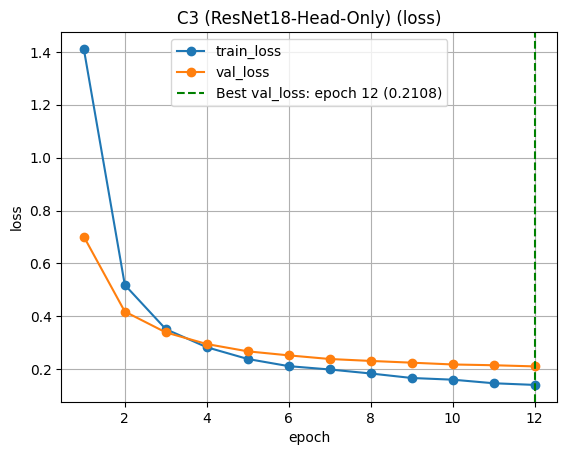

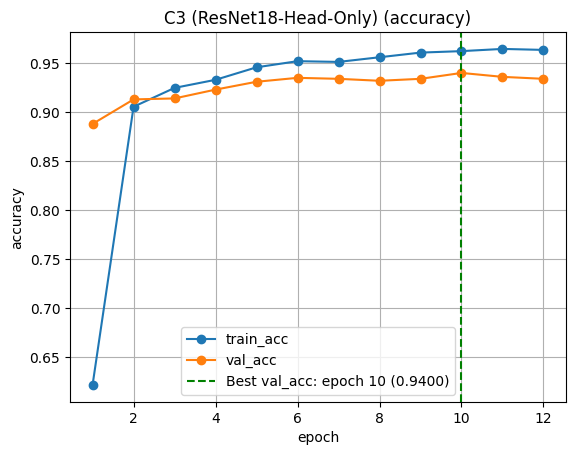

In [16]:
title = "C3 (ResNet18-Head-Only)"

res_c3 = run_experiment(
    title, 
    train_loader_resnet, 
    val_loader_resnet,
    get_resnet18_head_only(),
    lr=1e-3,
    weight_decay=0.0
)

plot_history(res_c3["history"], title)

Trainable: 8,398,858 (layer4 + fc)

Experiment C4 (ResNet18-FineTune) | lr=0.0001 weight_decay=0.0001 epochs=12
Trainable params: 8398858
Epoch 01/12 | train loss 0.8517, acc 0.760 | val loss 0.3142, acc 0.902 | 16.6s
Epoch 02/12 | train loss 0.1777, acc 0.963 | val loss 0.2379, acc 0.930 | 16.9s
Epoch 03/12 | train loss 0.0771, acc 0.991 | val loss 0.2090, acc 0.943 | 15.9s
Epoch 04/12 | train loss 0.0365, acc 0.999 | val loss 0.2024, acc 0.942 | 10.5s
Epoch 05/12 | train loss 0.0198, acc 1.000 | val loss 0.1958, acc 0.941 | 10.6s
Epoch 06/12 | train loss 0.0146, acc 1.000 | val loss 0.1947, acc 0.942 | 10.5s
Epoch 07/12 | train loss 0.0102, acc 1.000 | val loss 0.1950, acc 0.943 | 11.1s
Epoch 08/12 | train loss 0.0077, acc 1.000 | val loss 0.1931, acc 0.941 | 12.7s
Epoch 09/12 | train loss 0.0060, acc 1.000 | val loss 0.1930, acc 0.940 | 16.6s
Epoch 10/12 | train loss 0.0047, acc 1.000 | val loss 0.1924, acc 0.942 | 16.9s
Epoch 11/12 | train loss 0.0041, acc 1.000 | val loss 0.1942, 

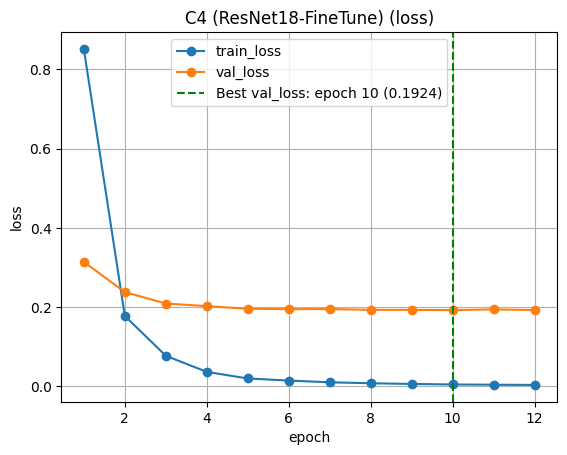

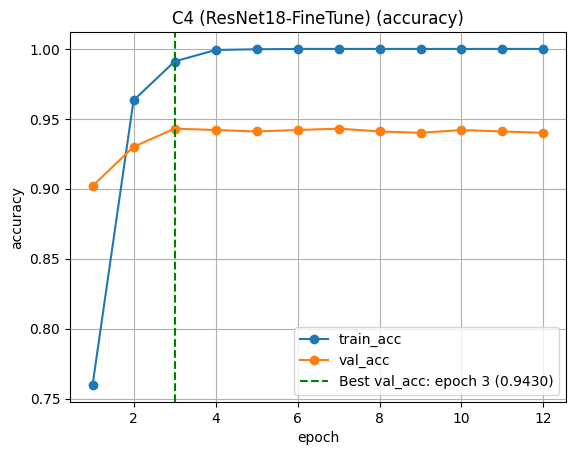

In [17]:
title = "C4 (ResNet18-FineTune)"

res_c4 = run_experiment(
    title,
    train_loader_resnet,
    val_loader_resnet, 
    get_resnet18_finetune(),
    lr=1e-4,
    weight_decay=1e-4
)

plot_history(res_c4["history"], title)

C4 - лучшая модель по `val_acc` - далее проверим её на test

In [18]:
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

In [19]:
test_loader_resnet = DataLoader(ds_test_resnet, batch_size=BATCH_SIZE, shuffle=False)
test_acc_c4 = accuracy_on_loader(res_c4["model"], test_loader_resnet)
print("Test acc (ResNet + FineTune):", round(test_acc_c4, 4))

Test acc (ResNet + FineTune): 0.949


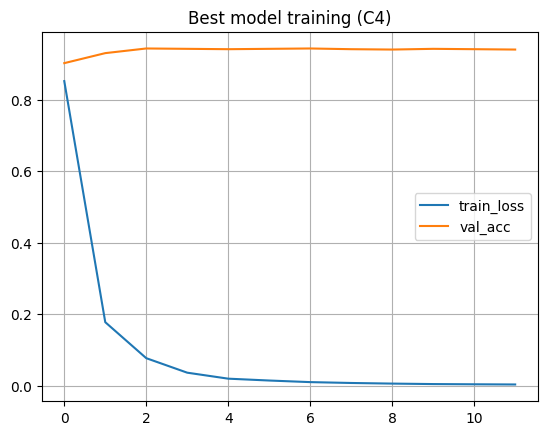

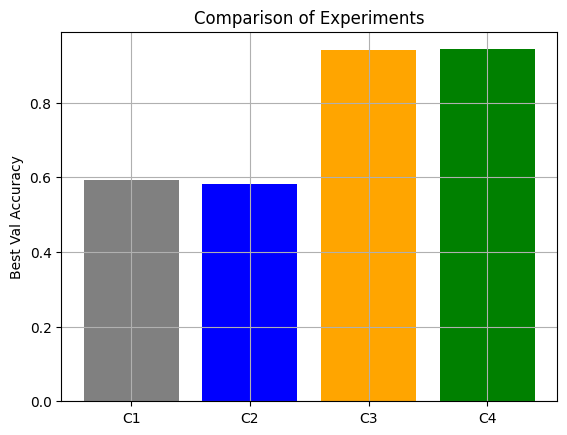

In [20]:
c1_val = res_c1["best_val_acc"]
c2_val = res_c2["best_val_acc"]
c3_val = res_c3["best_val_acc"]
c4_val = res_c4["best_val_acc"]

best_res = res_c4
history = best_res["history"]
test_acc = test_acc_c4

torch.save(best_res["model"].state_dict(), "artifacts/best_classifier.pt")

plt.figure()
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_acc"], label="val_acc")
plt.legend()
plt.title("Best model training (C4)")
plt.grid(True)
plt.savefig("artifacts/figures/classification_curves_best.png")
plt.show() 

plt.figure()
vals = [c1_val, c2_val, c3_val, c4_val]
names = ["C1","C2","C3","C4"]
plt.bar(names, vals, color=['gray', 'blue', 'orange', 'green'])
plt.title("Comparison of Experiments")
plt.ylabel("Best Val Accuracy")
plt.grid(True)
plt.savefig("artifacts/figures/classification_compare.png")
plt.show()

best_config = {
    "experiment_id": "C4", 
    "dataset": "STL10", 
    "seed": 42,
    "architecture": "ResNet18 (pretrained) -> partial finetune (layer4 + fc)",
    "optimizer": "Adam",
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "epochs_trained": EPOCHS,  
    "train_transforms": "weights.transforms() (Resize(232)->CenterCrop(224)->ToTensor()->Normalize(ImageNet))",
    "val_transforms": "weights.transforms() (Resize(232)->CenterCrop(224)->ToTensor()->Normalize(ImageNet))",
    "augmentations": "None",
    "best_val_accuracy": float(c4_val),
    "test_accuracy": float(test_acc)
}

with open("artifacts/best_classifier_config.json", "w") as f:
    json.dump(best_config, f, indent=4)

# Часть B - Детекция

In [21]:
class VOCDetectionDataset(Dataset):
    def __init__(self, root):
        self.dataset = VOCDetection(root=root, year='2012', image_set='val', download=True)

        self.map = {
            'aeroplane': 'airplane', 'bicycle': 'bicycle', 'bird': 'bird',
            'boat': 'boat', 'bottle': 'bottle', 'bus': 'bus', 'car': 'car',
            'cat': 'cat', 'chair': 'chair', 'cow': 'cow',
            'diningtable': 'dining table', 'dog': 'dog', 'horse': 'horse',
            'motorbike': 'motorcycle', 'person': 'person',
            'pottedplant': 'potted plant', 'sheep': 'sheep',
            'sofa': 'couch', 'train': 'train', 'tvmonitor': 'tv'
        }

        self.coco = [
            '__background__','person','bicycle','car','motorcycle','airplane','bus',
            'train','truck','boat','traffic light','fire hydrant','stop sign',
            'parking meter','bench','bird','cat','dog','horse','sheep','cow',
            'elephant','bear','zebra','giraffe','backpack','umbrella','handbag',
            'tie','suitcase','frisbee','skis','snowboard','sports ball','kite',
            'baseball bat','baseball glove','skateboard','surfboard','tennis racket',
            'bottle','wine glass','cup','fork','knife','spoon','bowl','banana',
            'apple','sandwich','orange','broccoli','carrot','hot dog','pizza',
            'donut','cake','chair','couch','potted plant','bed','dining table',
            'toilet','tv','laptop','mouse','remote','keyboard','cell phone',
            'microwave','oven','toaster','sink','refrigerator','book','clock',
            'vase','scissors','teddy bear','hair drier','toothbrush'
        ]

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, xml = self.dataset[idx]

        boxes, labels = [], []

        for obj in xml['annotation']['object']:
            b = obj['bndbox']
            name = self.map.get(obj['name'])

            if name in self.coco:
                boxes.append([
                    float(b['xmin']),
                    float(b['ymin']),
                    float(b['xmax']),
                    float(b['ymax'])
                ])
                labels.append(self.coco.index(name))

        boxes = torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0,4))
        labels = torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)

        img = F.pil_to_tensor(img).float()/255.0

        return img, {"boxes": boxes, "labels": labels}


dataset = VOCDetectionDataset('./data')
loader = DataLoader(dataset, batch_size=1, shuffle=False, collate_fn=lambda x: x)

In [22]:
model = fasterrcnn_resnet50_fpn(weights='DEFAULT').to(DEVICE)
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [23]:
def iou(a,b):
    x1,y1 = max(a[0],b[0]), max(a[1],b[1])
    x2,y2 = min(a[2],b[2]), min(a[3],b[3])

    inter = max(0,x2-x1)*max(0,y2-y1)
    union = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter/union if union else 0


def match(pb, pl, ps, gb, gl):
    used = [False]*len(gb)
    tp=fp=0
    ious=[]

    order = torch.argsort(ps, descending=True)

    for i in order:
        best, idx = 0, -1

        for j,(gbox,glabel) in enumerate(zip(gb,gl)):
            if used[j] or pl[i]!=glabel: continue
            val = iou(pb[i].cpu().numpy(), gbox.cpu().numpy())
            if val>best:
                best, idx = val, j

        if best>=0.5:
            tp+=1
            used[idx]=True
            ious.append(best)
        else:
            fp+=1

    fn = sum(not u for u in used)
    return tp,fp,fn,ious

In [24]:
def run(threshold, max_samples=300):
    tp = fp = fn = 0
    ious = []
    examples = []

    with torch.no_grad():
        for i, b in enumerate(loader):
            if i >= max_samples:
                break

            if i % 50 == 0:
                print(f"Processing {i}/{max_samples}")

            img, target = b[0]
            img = img.to(DEVICE)

            pred = model([img])[0]

            keep = pred['scores'] >= threshold

            pb = pred['boxes'][keep]
            pl = pred['labels'][keep]
            ps = pred['scores'][keep]

            tpp, fpp, fnn, ii = match(pb, pl, ps, target['boxes'], target['labels'])

            tp += tpp
            fp += fpp
            fn += fnn
            ious += ii

            if i < 4:
                examples.append((img.cpu(), target, pb.cpu(), ps.cpu()))

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    miou = float(np.mean(ious)) if ious else 0

    return {
        "precision": precision,
        "recall": recall,
        "mean_iou": miou,
        "tp": tp,
        "fp": fp,
        "fn": fn
    }, examples

m1, ex1 = run(0.3)
m2, ex2 = run(0.7)

print("V1:", m1)
print("V2:", m2)

Processing 0/300
Processing 50/300
Processing 100/300
Processing 150/300
Processing 200/300
Processing 250/300
Processing 0/300
Processing 50/300
Processing 100/300
Processing 150/300
Processing 200/300
Processing 250/300
V1: {'precision': 0.21037811745776347, 'recall': 0.6645489199491741, 'mean_iou': 0.8264366984367371, 'tp': 523, 'fp': 1963, 'fn': 264}
V2: {'precision': 0.4186643835616438, 'recall': 0.6213468869123253, 'mean_iou': 0.8326972723007202, 'tp': 489, 'fp': 679, 'fn': 298}


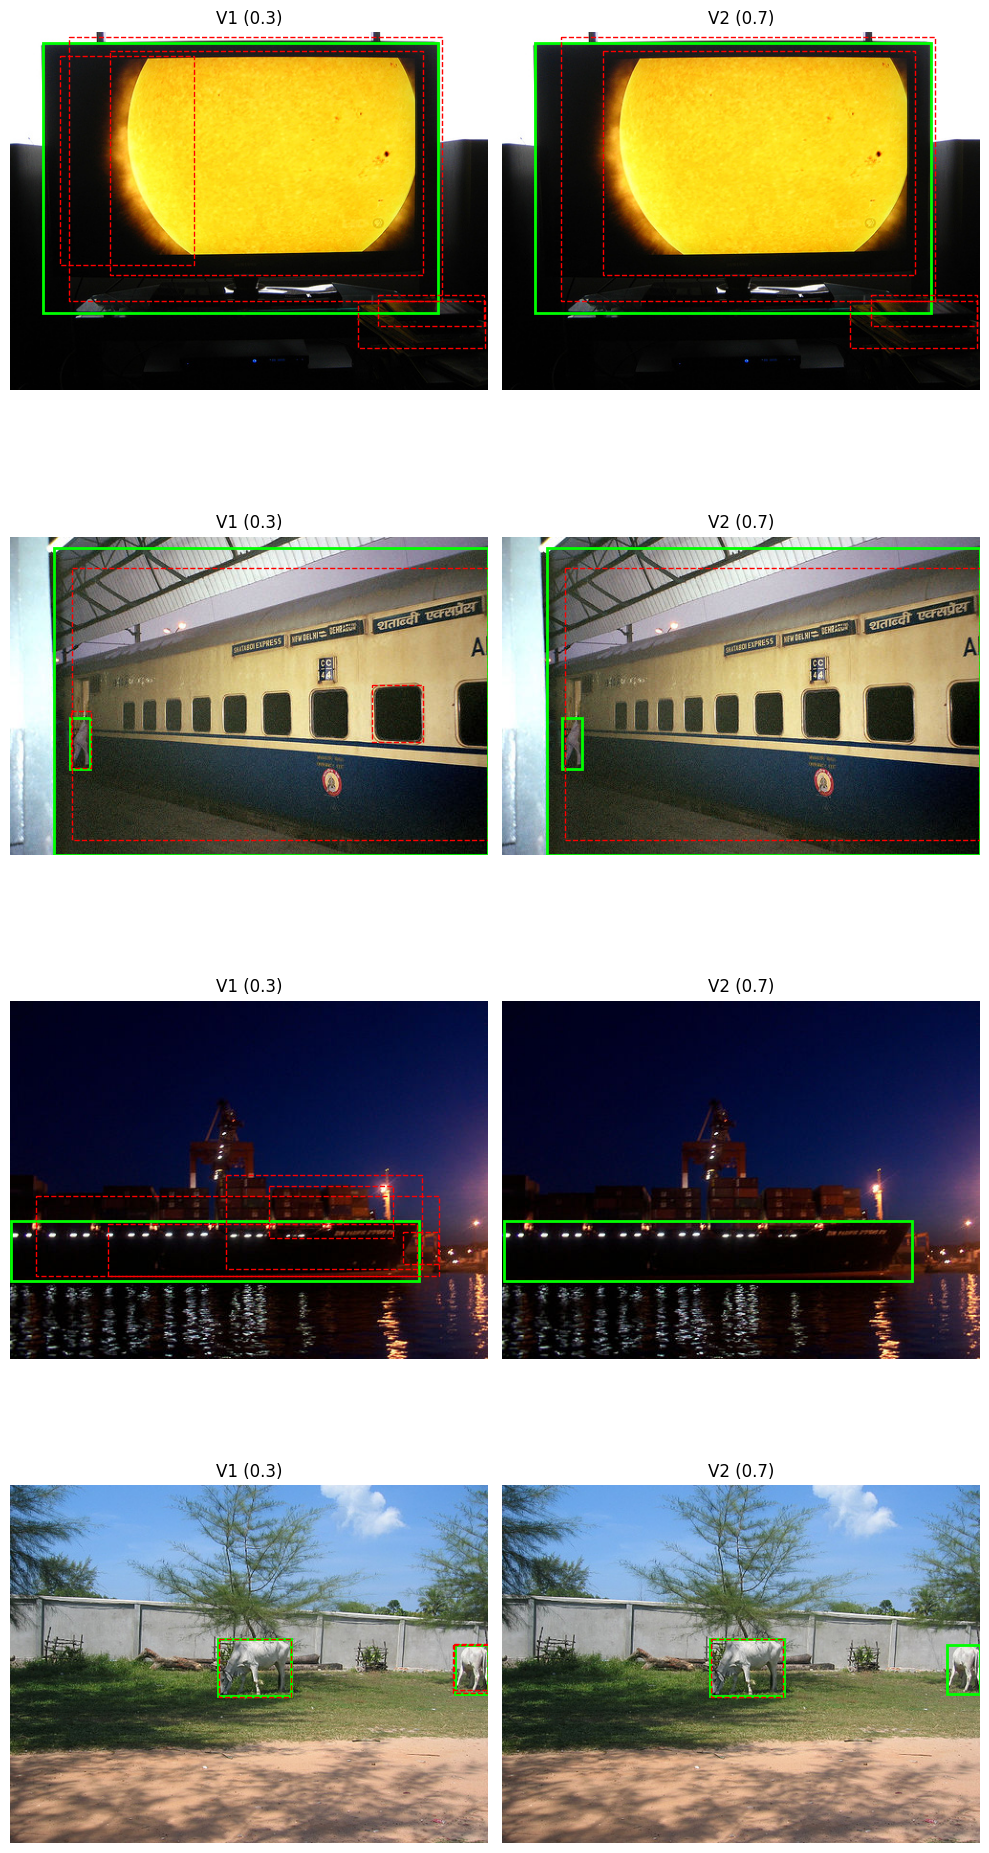

In [25]:
def draw(ax, img, gt, pb, ps):
    im = np.clip(img.permute(1,2,0).numpy(),0,1)
    ax.imshow(im)
    ax.axis('off')

    for b in gt['boxes']:
        b=b.numpy()
        ax.add_patch(patches.Rectangle((b[0],b[1]),b[2]-b[0],b[3]-b[1],
                                       edgecolor='lime',fill=False,linewidth=2))

    for b,s in zip(pb,ps):
        b=b.numpy()
        ax.add_patch(patches.Rectangle((b[0],b[1]),b[2]-b[0],b[3]-b[1],
                                       edgecolor='red',fill=False,linestyle='--'))

fig,ax = plt.subplots(4,2, figsize=(10,20))

for i in range(4):
    draw(ax[i,0], ex1[i][0], ex1[i][1], ex1[i][2], ex1[i][3])
    ax[i,0].set_title("V1 (0.3)")

    draw(ax[i,1], ex2[i][0], ex2[i][1], ex2[i][2], ex2[i][3])
    ax[i,1].set_title("V2 (0.7)")

plt.tight_layout()
plt.savefig("artifacts/figures/detection_examples.png", dpi=150)
plt.show()

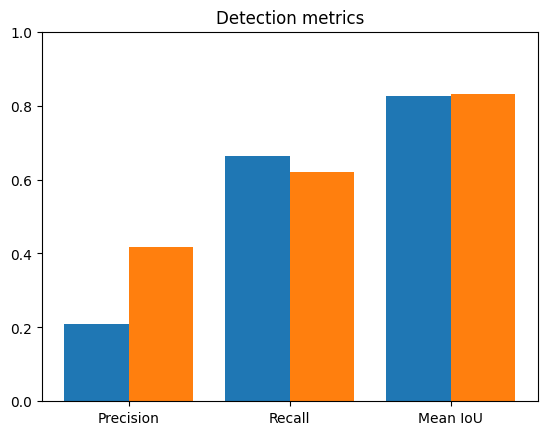

In [26]:
names = ["Precision","Recall","Mean IoU"]
v1 = [m1['precision'], m1['recall'], m1['mean_iou']]
v2 = [m2['precision'], m2['recall'], m2['mean_iou']]

plt.figure()
x = np.arange(3)
plt.bar(x-0.2,v1,0.4)
plt.bar(x+0.2,v2,0.4)
plt.xticks(x,names)
plt.ylim(0,1)
plt.title("Detection metrics")
plt.savefig("artifacts/figures/detection_metrics.png", dpi=150)
plt.show()

In [27]:
with open("artifacts/runs.csv", "w", newline="") as f:
    writer = csv.writer(f)

    writer.writerow([
        "experiment_id","task","dataset","seed","model_summary",
        "optimizer","lr","epochs_trained",
        "best_val_accuracy","test_accuracy",
        "precision","recall","mean_iou","notes"
    ])

    writer.writerow(["C1","classification","STL10",RANDOM_STATE,"SimpleCNN","Adam",1e-3,EPOCHS,c1_val,"","","","","96x96 STL10 norm"])
    writer.writerow(["C2","classification","STL10",RANDOM_STATE,"SimpleCNN+aug","Adam",1e-3,EPOCHS,c2_val,"","","","","96x96 STL10 norm + aug"])
    writer.writerow(["C3","classification","STL10",RANDOM_STATE,"ResNet18 head","Adam",1e-3,EPOCHS,c3_val,"","","","","weights.transforms() 224x224"])
    writer.writerow(["C4","classification","STL10",RANDOM_STATE,"ResNet18 finetune","Adam",1e-4,EPOCHS,c4_val,test_acc_c4,"","","","weights.transforms() 224x224"])

    writer.writerow(["V1","detection","Pascal VOC",RANDOM_STATE,"FasterRCNN","","","", "", "", *v1, "thr=0.3"])
    writer.writerow(["V2","detection","Pascal VOC",RANDOM_STATE,"FasterRCNN","","","", "", "", *v2 ,"thr=0.7"])